二、数据可视化与分析

数据总览：
商品总数: 48955
主要类别数量: 20
店铺数量: 19062

价格统计：
count    48955.00
mean        39.27
std         44.39
min          0.01
25%         28.69
50%         39.39
75%         39.39
max       4190.00
Name: price, dtype: object

评分统计：
count    48955.000
mean         4.144
std          0.639
min          1.000
25%          3.900
50%          4.300
75%          4.500
max          5.000
Name: average_rating, dtype: object

评论数统计：
count     48955.00
mean        285.65
std        1371.51
min           1.00
25%           7.00
50%          32.00
75%         162.00
max      112609.00
Name: rating_number, dtype: object


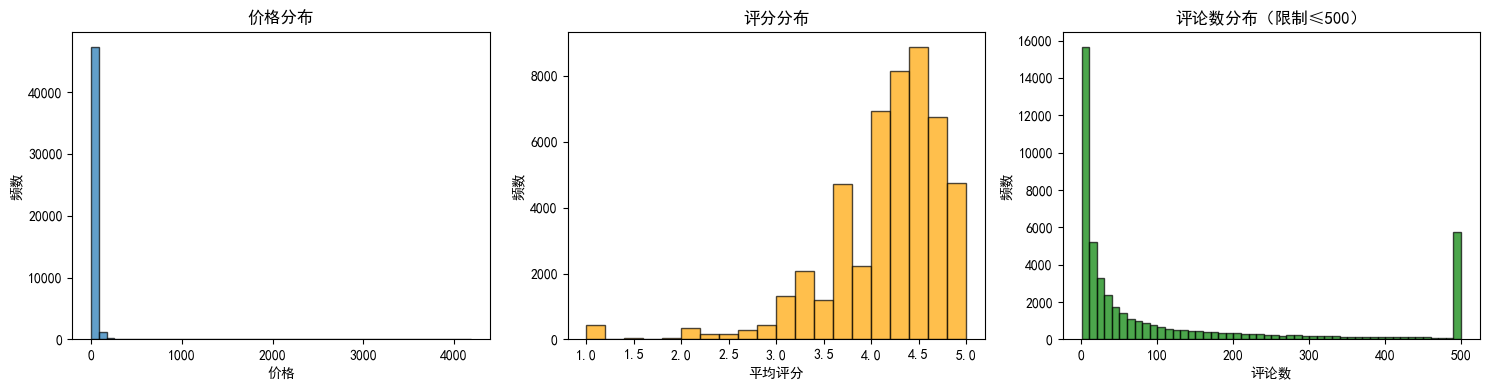

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示（如果使用中文标签）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取清洗后的数据
df = pd.read_csv('D:/workspace/Data_analysis_of_clothing_products/data_clean.csv')

print("数据总览：")
print(f"商品总数: {len(df)}")
print(f"主要类别数量: {df['main_category'].nunique()}")
print(f"店铺数量: {df['store'].nunique()}")

# 价格描述
print("\n价格统计：")
print(df['price'].describe().apply(lambda x: f'{x:.2f}'))

# 评分描述
print("\n评分统计：")
print(df['average_rating'].describe().apply(lambda x: f'{x:.3f}'))

# 评论数描述
print("\n评论数统计：")
print(df['rating_number'].describe().apply(lambda x: f'{x:.2f}'))

# 绘制价格分布直方图
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('价格分布')
axes[0].set_xlabel('价格')
axes[0].set_ylabel('频数')

axes[1].hist(df['average_rating'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('评分分布')
axes[1].set_xlabel('平均评分')
axes[1].set_ylabel('频数')

# 评论数分布（可能右偏，取对数或限制范围）
axes[2].hist(df['rating_number'].clip(upper=500), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_title('评论数分布（限制≤500）')
axes[2].set_xlabel('评论数')
axes[2].set_ylabel('频数')

plt.tight_layout()
plt.show()

各主要类别统计（按商品数排序）：
                           product_count  avg_price  avg_rating  total_reviews
main_category                                                                 
AMAZON FASHION                     47419  39.388318    4.143347       13644664
Sports & Outdoors                    507  53.820824    4.205720          99804
Amazon Home                          269  28.785581    4.118216          67981
All Beauty                           158  16.363068    3.982911          46318
Tools & Home Improvement             136  30.570602    4.357353          37513
Toys & Games                         111  27.282105    4.053153          22544
Health & Personal Care                73  25.112857    4.076712          15710
Office Products                       62  16.601613    4.232258          13826
Arts, Crafts & Sewing                 50  12.152143    4.120000          10099
Baby                                  42  23.305714    4.276190           6346
Industrial & Scientific            

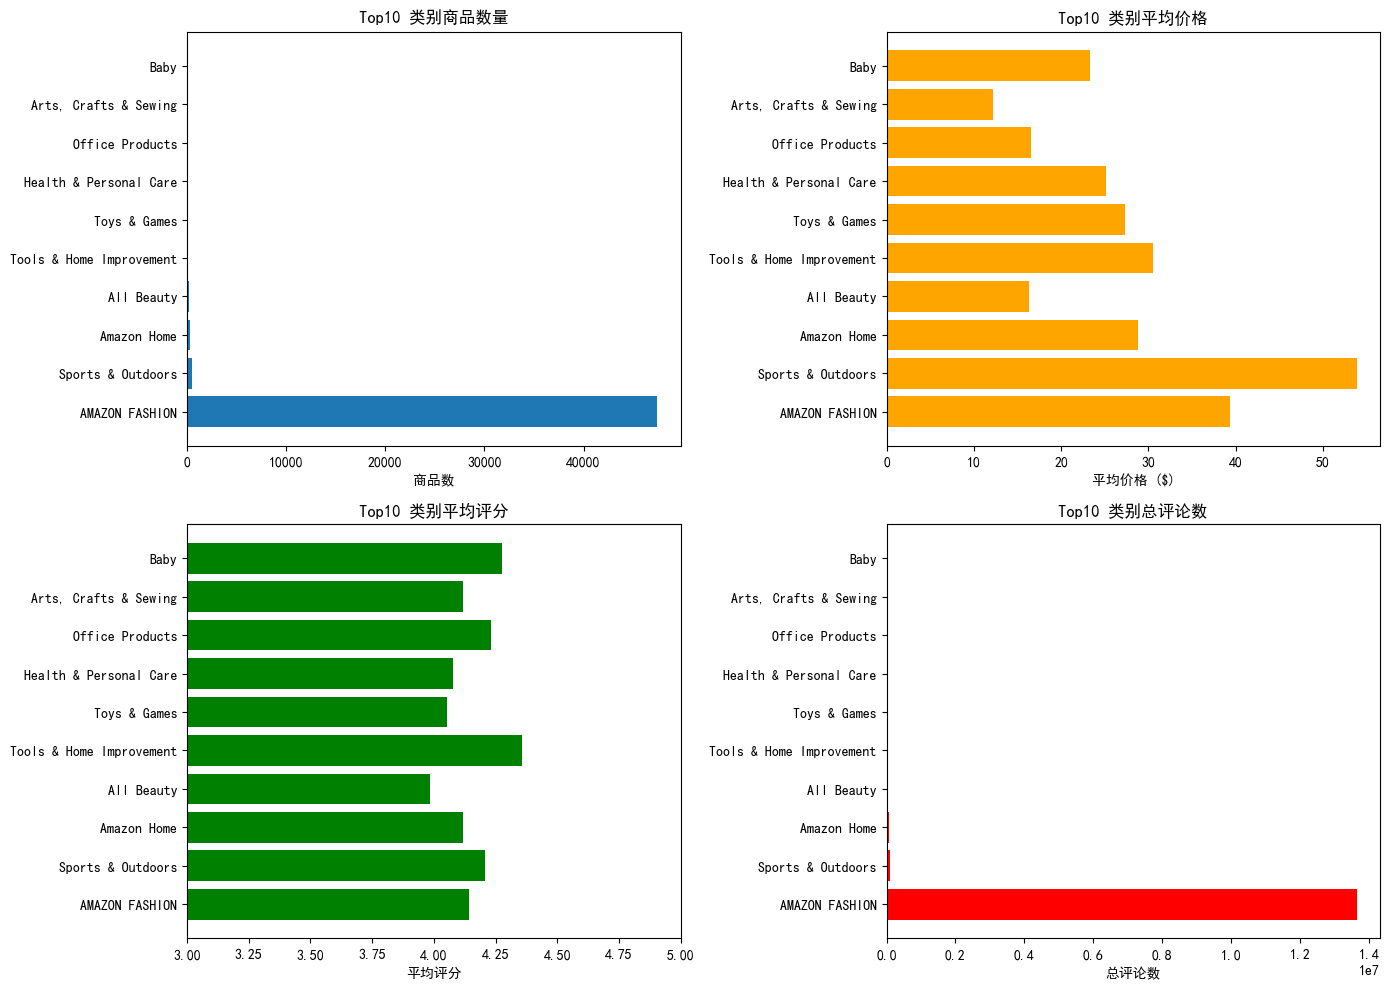

In [2]:
# 类别分析
category_stats = df.groupby('main_category').agg({
    'title': 'count',                     # 商品数量
    'price': 'mean',                       # 平均价格
    'average_rating': 'mean',              # 平均评分
    'rating_number': 'sum'                  # 总评论数
}).rename(columns={
    'title': 'product_count',
    'price': 'avg_price',
    'average_rating': 'avg_rating',
    'rating_number': 'total_reviews'
}).sort_values('product_count', ascending=False)

print("各主要类别统计（按商品数排序）：")
print(category_stats)

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 商品数量分布
axes[0,0].barh(category_stats.index[:10], category_stats['product_count'][:10])
axes[0,0].set_title('Top10 类别商品数量')
axes[0,0].set_xlabel('商品数')

# 平均价格分布
axes[0,1].barh(category_stats.index[:10], category_stats['avg_price'][:10], color='orange')
axes[0,1].set_title('Top10 类别平均价格')
axes[0,1].set_xlabel('平均价格 ($)')

# 平均评分分布
axes[1,0].barh(category_stats.index[:10], category_stats['avg_rating'][:10], color='green')
axes[1,0].set_title('Top10 类别平均评分')
axes[1,0].set_xlabel('平均评分')
axes[1,0].set_xlim(3, 5)  # 评分范围

# 总评论数分布
axes[1,1].barh(category_stats.index[:10], category_stats['total_reviews'][:10], color='red')
axes[1,1].set_title('Top10 类别总评论数')
axes[1,1].set_xlabel('总评论数')

plt.tight_layout()
plt.show()

Top20 店铺（按总评论数）：
                         product_count  total_reviews  avg_rating
store                                                            
Amazon Essentials                  144         296414    4.345833
Skechers                           388         143430    4.256701
Gildan                              28         137374    4.271429
Under Armour                       307         119349    4.428664
Champion                           121         110807    4.240496
TRAVANDO                             1         110381    4.400000
adidas                             457         106911    4.362144
Nike                               454          91731    4.379956
Hanes                              112          82776    4.211607
HOPLYNN                              5          78309    4.420000
Crocs                              151          72579    4.297351
Travelambo                           4          70146    4.425000
Fruit of the Loom                   44          66015    4.

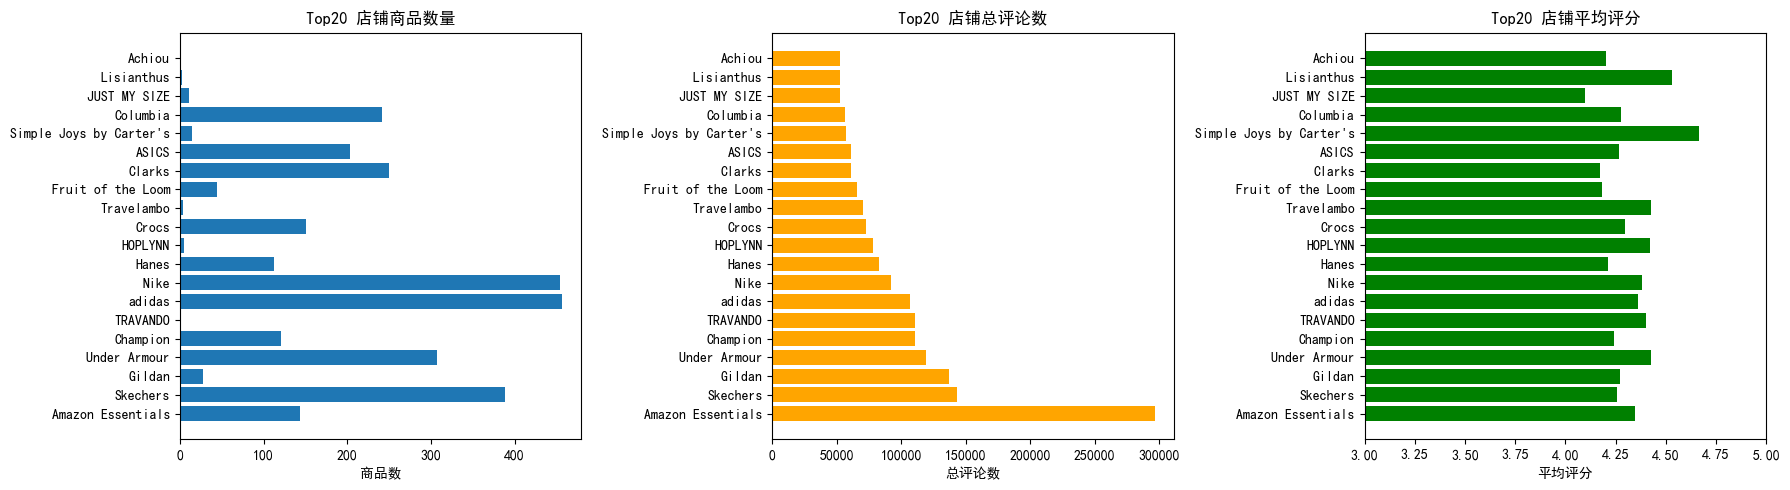

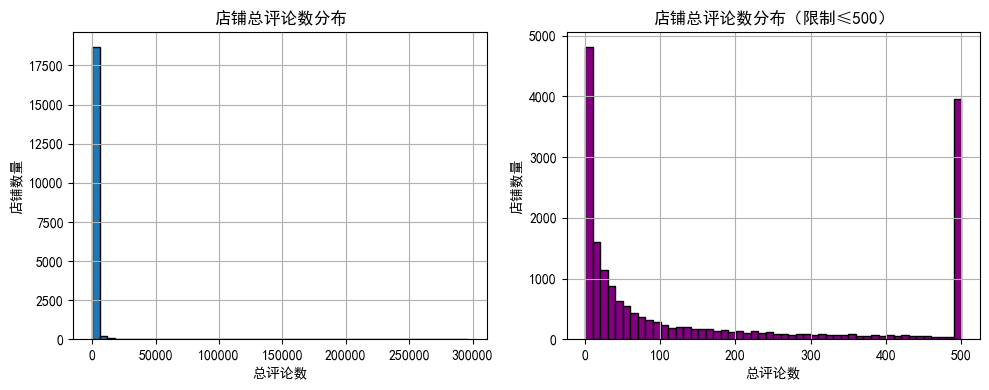

In [3]:
# 店铺分析
store_stats = df.groupby('store').agg({
    'title': 'count',
    'rating_number': 'sum',
    'average_rating': 'mean'
}).rename(columns={
    'title': 'product_count',
    'rating_number': 'total_reviews',
    'average_rating': 'avg_rating'
})

# 按总评论数排序，取前20
top_stores_by_reviews = store_stats.sort_values('total_reviews', ascending=False).head(20)
print("Top20 店铺（按总评论数）：")
print(top_stores_by_reviews)

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 商品数量
axes[0].barh(top_stores_by_reviews.index, top_stores_by_reviews['product_count'])
axes[0].set_title('Top20 店铺商品数量')
axes[0].set_xlabel('商品数')

# 总评论数
axes[1].barh(top_stores_by_reviews.index, top_stores_by_reviews['total_reviews'], color='orange')
axes[1].set_title('Top20 店铺总评论数')
axes[1].set_xlabel('总评论数')

# 平均评分
axes[2].barh(top_stores_by_reviews.index, top_stores_by_reviews['avg_rating'], color='green')
axes[2].set_title('Top20 店铺平均评分')
axes[2].set_xlabel('平均评分')
axes[2].set_xlim(3, 5)

plt.tight_layout()
plt.show()

# 店铺评论数的分布（观察长尾）
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
store_stats['total_reviews'].hist(bins=50, edgecolor='black')
plt.title('店铺总评论数分布')
plt.xlabel('总评论数')
plt.ylabel('店铺数量')

plt.subplot(1,2,2)
store_stats['total_reviews'].clip(upper=500).hist(bins=50, edgecolor='black', color='purple')
plt.title('店铺总评论数分布（限制≤500）')
plt.xlabel('总评论数')
plt.ylabel('店铺数量')
plt.tight_layout()
plt.show()

各价格区间评分统计：
  price_range      mean  count
0        0-10  4.120451   1731
1       10-20  4.254201   6474
2       20-30  4.241600   5161
3       30-40  4.089043  30327
4       40-50  4.232852   1455
5      50-100  4.242099   2620
6     100-200  4.238838    878
7     200-500  4.254054    259
8    500-1000  4.315385     39
9       1000+  4.063636     11


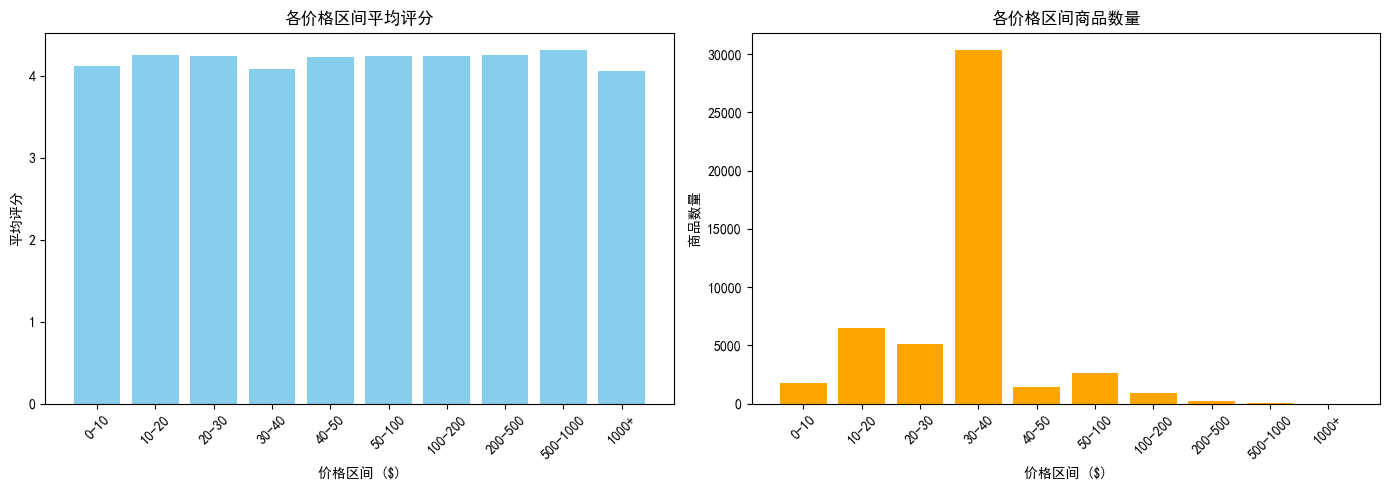


高性价比商品数量: 10496
示例：


,title,price,average_rating,rating_number
122,JanSport Black Label Superbreak Backpack - 155...,16.601613,5.0,6
15,Trendy Summer Chef's Apron Pineapple Fruit Pho...,19.990000,5.0,1
48758,Collections Etc Cute Patriotic Kitty with Paw ...,26.980000,5.0,1
48722,Azure Color Round Created Opal Floating Locket...,7.990000,5.0,1
38424,OPTEXX RFID Blocking Wallet Marco Black TÜV Te...,16.601613,5.0,2
38306,Waffle Robe Full Length Soft Spa Bathrobe Hous...,20.880000,5.0,1
5845,Mens Slim Fit V Neck Blouse Metallic Shiny Wet...,10.990000,5.0,1
38633,Cottage Garden for A Dear Sister Special to Me...,36.950000,5.0,3
38602,Tai Gold Stick Stackable Gold-Plated Brass Ring,18.420000,5.0,2
38547,Big Cousin (Only Grandchild crossed out) Cute ...,13.990000,5.0,1


In [4]:
# 价格分箱
price_bins = [0, 10, 20, 30, 40, 50, 100, 200, 500, 1000, 5000]
price_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-100', '100-200', '200-500', '500-1000', '1000+']
df['price_range'] = pd.cut(df['price'], bins=price_bins, labels=price_labels, right=False)

# 各价格区间的平均评分和商品数
price_rating = df.groupby('price_range', observed=False)['average_rating'].agg(['mean', 'count']).reset_index()
print("各价格区间评分统计：")
print(price_rating)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(price_rating['price_range'], price_rating['mean'], color='skyblue')
axes[0].set_title('各价格区间平均评分')
axes[0].set_xlabel('价格区间 ($)')
axes[0].set_ylabel('平均评分')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(price_rating['price_range'], price_rating['count'], color='orange')
axes[1].set_title('各价格区间商品数量')
axes[1].set_xlabel('价格区间 ($)')
axes[1].set_ylabel('商品数量')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 找出高性价比商品（价格低于平均，评分高于平均）
avg_price = df['price'].mean()
avg_rating = df['average_rating'].mean()
high_value = df[(df['price'] < avg_price) & (df['average_rating'] > avg_rating)]
print(f"\n高性价比商品数量: {len(high_value)}")
print("示例：")
high_value[['title', 'price', 'average_rating', 'rating_number']].sort_values('average_rating', ascending=False).head(10)

In [5]:
import ast
def safe_eval_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []
df['features_list'] = df['features'].apply(safe_eval_list)

最常见的20个特征词（仅使用 nltk 停用词）：
size: 21944
100%: 18046
women: 17260
wash: 12814
fit: 12540
wear: 11979
perfect: 11978
soft: 11419
design: 10854
gift: 10724
made: 10681
comfortable: 10454
cotton: 10417
dress: 10214
casual: 9822
fabric: 8894
closuremachine: 8517
quality: 8432
day: 8202
long: 8180


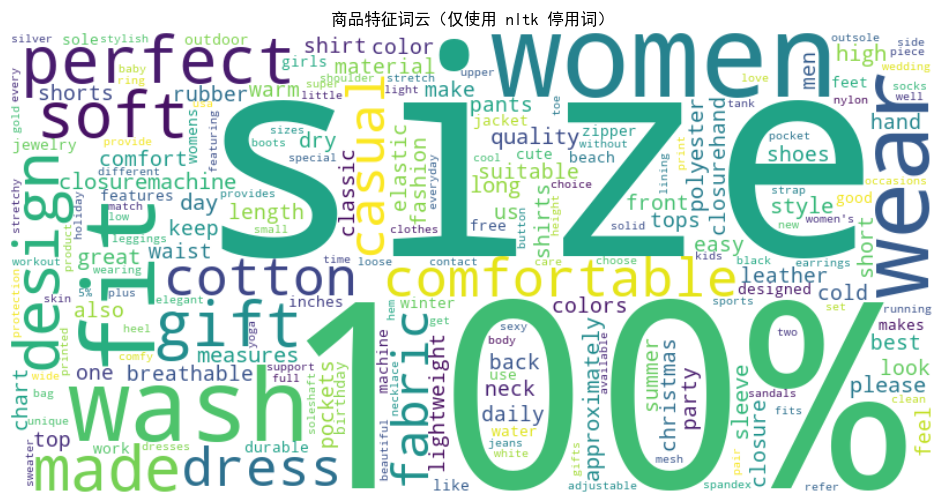

In [8]:
import ast
from collections import Counter
import wordcloud
import nltk
from nltk.corpus import stopwords

# 下载停用词（如果尚未下载）
nltk.download('stopwords', quiet=True)

# 获取 nltk 英文停用词集合
stop_words = set(stopwords.words('english'))

# 确保 features_list 列存在（如果还没有，需要先解析）
def safe_eval_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []

if 'features_list' not in df.columns:
    df['features_list'] = df['features'].apply(safe_eval_list)

# 收集清洗后的特征词
all_features = []
for feat_list in df['features_list']:
    for feat in feat_list:
        if isinstance(feat, str):
            # 转为小写，并按空格分词
            words = feat.lower().split()
            for word in words:
                # 去除标点符号
                word_clean = word.strip('.,;:()"\'')
                # 过滤：去除停用词、长度小于2的词、纯数字
                if word_clean and word_clean not in stop_words and len(word_clean) > 1 and not word_clean.isdigit():
                    all_features.append(word_clean)

# 统计词频
feature_counter = Counter(all_features)
top_features = feature_counter.most_common(20)
print("最常见的20个特征词（仅使用 nltk 停用词）：")
for word, count in top_features:
    print(f"{word}: {count}")

# 绘制词云
wordcloud_img = wordcloud.WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(feature_counter)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud_img, interpolation='bilinear')
plt.axis('off')
plt.title('商品特征词云（仅使用 nltk 停用词）')
plt.show()

评论数最多的20个商品：
                                                   title   main_category  \
45578     Gildan Men's Underwear Boxer Briefs, Multipack  AMAZON FASHION   
21415  TRAVANDO Mens Slim Wallet with Money Clip AUST...  AMAZON FASHION   
15453  Travelambo Womens Wallet RFID Blocking Bifold ...  AMAZON FASHION   
2822   HOPLYNN Neoprene Sweat Waist Trainer Corset Tr...  AMAZON FASHION   
9563   Achiou Winter Gloves for Men Women, Touch Scre...  AMAZON FASHION   
34157  Wrangler Authentics Men's Long Sleeve Quilted ...  AMAZON FASHION   
16637            Lisianthus Women Belt Buckle Fedora Hat  AMAZON FASHION   
28177  Champion Men's Pants, Everyday Cotton Pants fo...  AMAZON FASHION   
14556  NY Threads Women Fleece Shawl Collar Bathrobe ...  AMAZON FASHION   
13807  HALLUCI Women's Cross Band Soft Plush Fleece H...  AMAZON FASHION   
38137  SHAPERMINT High Waisted Body Shaper Shorts Sha...  AMAZON FASHION   
37829  Iseasoo Copper Compression Socks For Men & Wom...  AMAZON FASHION   

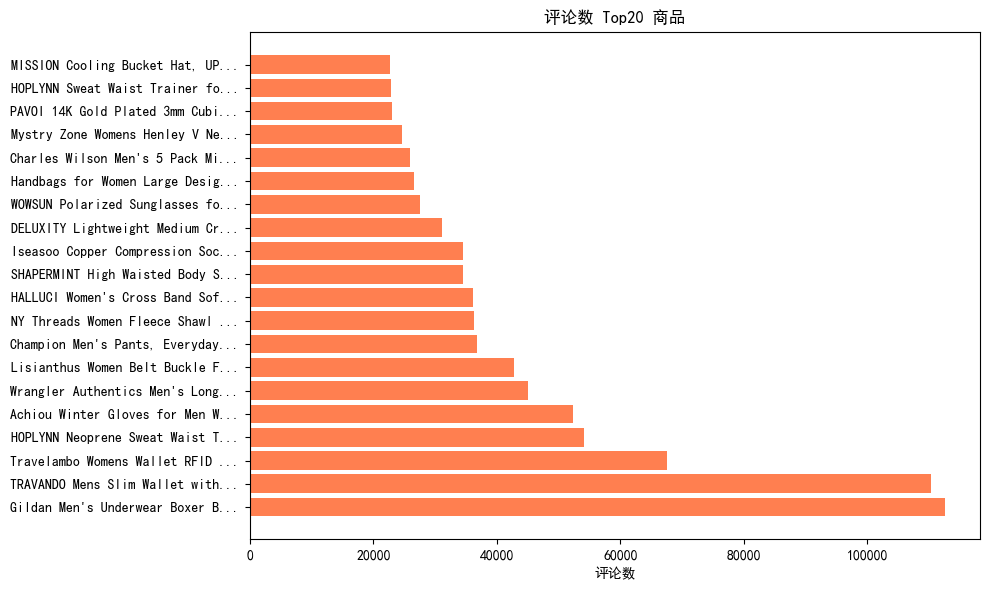

In [9]:
# 按评论数排序，取前20
top_reviewed = df.nlargest(20, 'rating_number')[['title', 'main_category', 'store', 'price', 'average_rating', 'rating_number']]
print("评论数最多的20个商品：")
print(top_reviewed)

# 可视化
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(range(len(top_reviewed)), top_reviewed['rating_number'], color='coral')
ax.set_yticks(range(len(top_reviewed)))
ax.set_yticklabels(top_reviewed['title'].str[:30] + '...')  # 标题截断显示
ax.set_xlabel('评论数')
ax.set_title('评论数 Top20 商品')
plt.tight_layout()
plt.show()

In [10]:
# 筛选评分≥4.5且评论数≤10的商品
potential_stars = df[(df['average_rating'] >= 4.5) & (df['rating_number'] <= 10)]
print(f"高评分低评论数商品数量：{len(potential_stars)}")
print("示例（按评分降序）：")
potential_stars[['title', 'main_category', 'store', 'price', 'average_rating', 'rating_number']].sort_values('average_rating', ascending=False).head(10)

高评分低评论数商品数量：6617
示例（按评分降序）：


,title,main_category,store,price,average_rating,rating_number
48954,DUINN Hiking Womens Sandal Adjustable Stylish ...,AMAZON FASHION,DUINN,39.388318,5.0,4
1,St Michael Antique Pendant Necklaces,AMAZON FASHION,St Michael,39.388318,5.0,2
8,Buff UV Headband Buff,AMAZON FASHION,BUFF,39.388318,5.0,5
11,Buckle-Down Unisex-Adult's Web Belt Street Fig...,AMAZON FASHION,Buckle-Down,39.388318,5.0,2
15,Trendy Summer Chef's Apron Pineapple Fruit Pho...,Amazon Home,Tim And Ted,19.990000,5.0,1
16,Sugoi Women's Verve Short Sleeve Top,AMAZON FASHION,SUGOi,39.388318,5.0,2
23,Fit Over RX Glasses Sunglasses - 50% Off - Bon...,AMAZON FASHION,Solar Shield,39.388318,5.0,1
48951,Lucky Brand Men's - Faded Black Triumph Motorc...,AMAZON FASHION,Lucky Brand,39.388318,5.0,1
48876,Sundray Women's Plus Size Knott T-Shirt Round ...,AMAZON FASHION,Sundray,39.388318,5.0,1
48817,Nine West Punch Love Wristlet,AMAZON FASHION,NINE WEST,39.388318,5.0,4


In [13]:
import ast

def has_video_by_title(video_data):
    """
    判断视频字段是否包含有效视频
    规则：解析 video 字段，如果得到列表，且列表中至少有一个元素是字典并且包含 'title' 键，则认为有视频。
    """
    if pd.isna(video_data):
        return 0
    # 如果已经是列表
    if isinstance(video_data, list):
        for item in video_data:
            if isinstance(item, dict) and 'title' in item:
                return 1
        return 0
    # 如果是字符串，尝试解析
    if isinstance(video_data, str):
        try:
            parsed = ast.literal_eval(video_data)
            if isinstance(parsed, list):
                for item in parsed:
                    if isinstance(item, dict) and 'title' in item:
                        return 1
        except:
            pass
    return 0

# 应用函数创建 has_video 列
df['has_video'] = df['videos'].apply(has_video_by_title)

# 检查结果
print(f"有视频的商品数量: {df['has_video'].sum()}")
print(f"无视频的商品数量: {(df['has_video'] == 0).sum()}")

# 如果有视频商品数量为0，打印一些 video 列示例用于调试
if df['has_video'].sum() == 0:
    print("\n警告：未检测到有视频的商品，请检查 video 列数据格式。")
    print("video 列前5个示例：")
    for i, v in enumerate(df['videos'].head(5)):
        print(f"{i}: {v}")

有视频的商品数量: 6657
无视频的商品数量: 42298



有视频与无视频商品对比：
          rating_number               average_rating      price
                   mean median  count           mean       mean
has_video                                                      
0            262.986240   27.0  42298       4.133453  39.358818
1            429.631215   89.0   6657       4.213054  38.732153


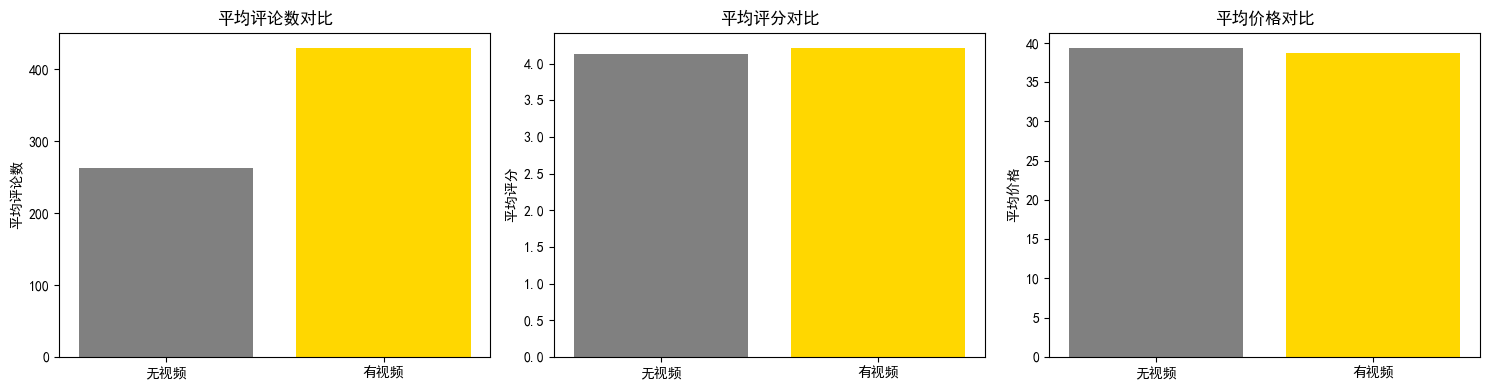

C:\Users\ZhuanZ1\AppData\Local\Temp\ipykernel_23752\2871415385.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=['无视频', '有视频'])


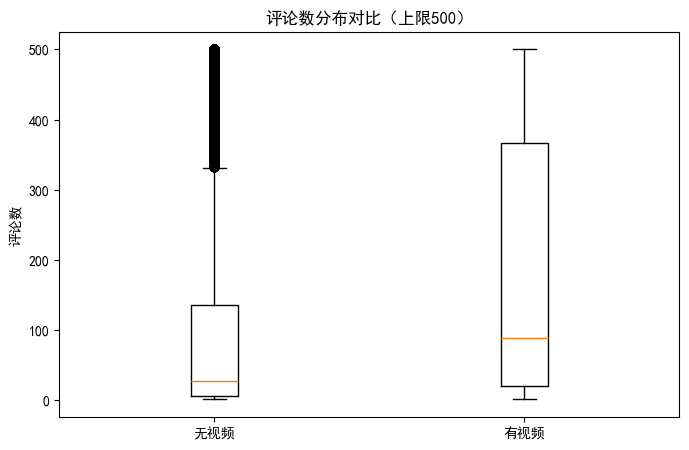

In [14]:
# 比较有视频和无视频的商品
video_stats = df.groupby('has_video').agg({
    'rating_number': ['mean', 'median', 'count'],
    'average_rating': 'mean',
    'price': 'mean'
})
print("\n有视频与无视频商品对比：")
print(video_stats)

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# 获取数据
groups = video_stats.index.tolist()
mean_reviews = video_stats['rating_number']['mean'].values
mean_ratings = video_stats['average_rating']['mean'].values
mean_prices = video_stats['price']['mean'].values
x_pos = range(len(groups))
labels = ['无视频' if g == 0 else '有视频' for g in groups]

# 平均评论数
axes[0].bar(x_pos, mean_reviews, color=['gray', 'gold'][:len(groups)])
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels)
axes[0].set_title('平均评论数对比')
axes[0].set_ylabel('平均评论数')

# 平均评分
axes[1].bar(x_pos, mean_ratings, color=['gray', 'gold'][:len(groups)])
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels)
axes[1].set_title('平均评分对比')
axes[1].set_ylabel('平均评分')

# 平均价格
axes[2].bar(x_pos, mean_prices, color=['gray', 'gold'][:len(groups)])
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(labels)
axes[2].set_title('平均价格对比')
axes[2].set_ylabel('平均价格')

plt.tight_layout()
plt.show()

# 可选：箱线图展示评论数分布差异（如果两组数据量都较大）
if len(groups) == 2:
    fig, ax = plt.subplots(figsize=(8,5))
    data_to_plot = [df[df['has_video']==0]['rating_number'].clip(upper=500), 
                    df[df['has_video']==1]['rating_number'].clip(upper=500)]
    ax.boxplot(data_to_plot, labels=['无视频', '有视频'])
    ax.set_title('评论数分布对比（上限500）')
    ax.set_ylabel('评论数')
    plt.show()